<a href="https://colab.research.google.com/github/Karishmaaa22/ML-safety/blob/main/ML_safety_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exercise 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_path = "/content/drive/MyDrive/Data2/train"
test_path = "/content/drive/MyDrive/Data2/test"
validation_path="/content/drive/MyDrive/Data2/validation"

In [ ]:
import pandas as pd
labels_train = pd.read_csv(train_path + "/labels.csv")
labels_test = pd.read_csv(test_path + "/labels.csv")
labels_validation=pd.read_csv(validation_path+"/labels.csv")

In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
print(labels_train.head())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  


Exercise 3.4

In [ ]:
import os
train_images = os.listdir(train_path+"/rgb-front")
test_images = os.listdir(test_path+"/rgb-front")
print("Number of Training Images:", len(train_images))
print("Number of Test Images:", len(test_images))

Number of Training Images: 7200
Number of Test Images: 3600


In [ ]:
labels=["has_pedestrian","has_traffic_light","has_vehicle"]

for label in labels:
  print(f"Class Distribution: {label}")
  distribution =(labels_train[label].value_counts())
  print(distribution)

Class Distribution: has_pedestrian
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64
Class Distribution: has_traffic_light
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64
Class Distribution: has_vehicle
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


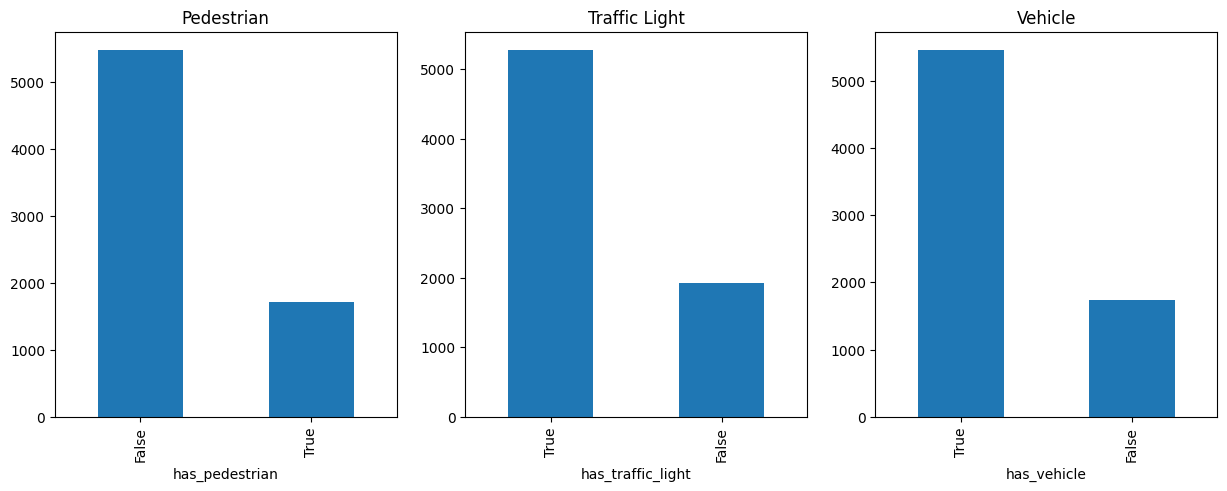

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15,5))
labels_train['has_pedestrian'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    title='Pedestrian'
)
labels_train['has_traffic_light'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    title='Traffic Light'
)
labels_train['has_vehicle'].value_counts().plot(
    kind='bar',
    ax=axes[2],
    title='Vehicle'
)
plt.show()

In [ ]:
print(labels_train.columns)

Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [ ]:
print(labels_train.iloc[0])

frame                    0
has_traffic_light    False
has_pedestrian       False
has_vehicle           True
px_traffic_light         0
px_pedestrian            0
px_vehicle              85
Name: 0, dtype: object


In [ ]:
train_rgb_path=train_path+"/rgb-front"
test_rgb_path=test_path+"/rgb-front"
validation_rgb_path=validation_path+"/rgb-front"

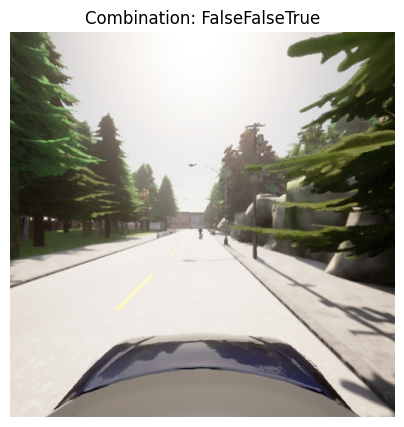

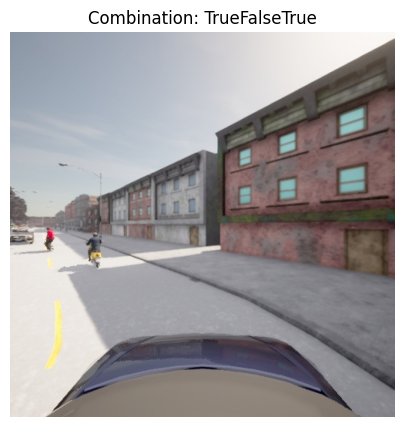

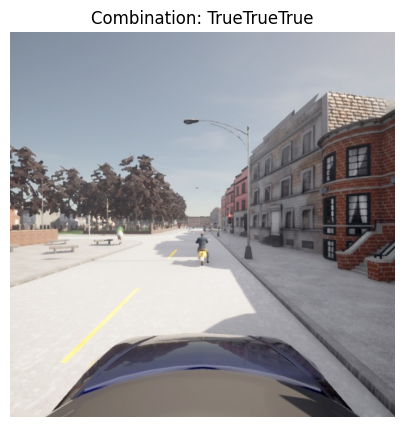

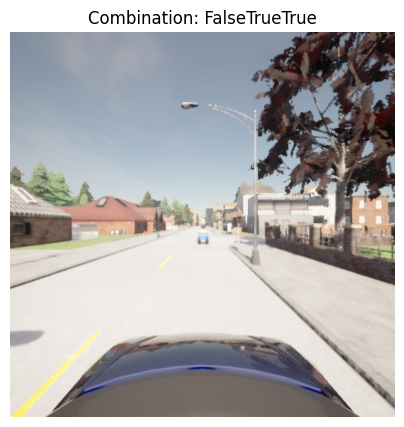

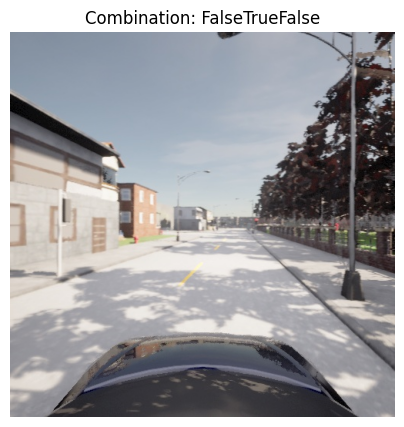

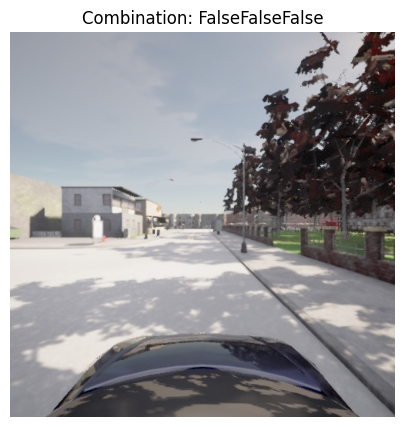

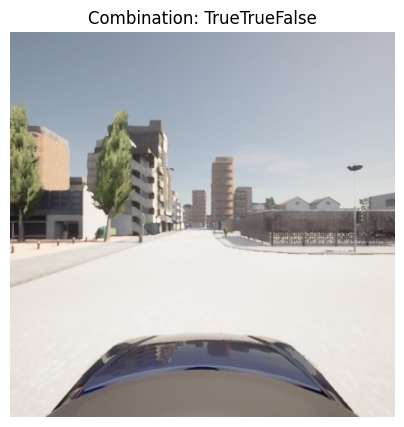

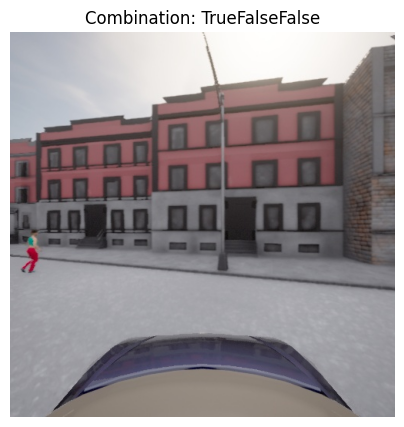

In [ ]:
from PIL import Image
labels_train['combination'] = (
    labels_train['has_pedestrian'].astype(str)
    + labels_train['has_traffic_light'].astype(str)
    + labels_train['has_vehicle'].astype(str)
)
unique_combinations = labels_train['combination'].unique()
for combo in unique_combinations:
    sample = labels_train[
        labels_train['combination'] == combo
    ].iloc[0]
    image_name = f"{sample['frame']:06d}.jpg"
    image_path = os.path.join(
        train_rgb_path,
        image_name
    )
    image = Image.open(image_path)
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.title(f"Combination: {combo}")
    plt.axis('off')
    plt.show()

Exercise 3.5

In [ ]:
import torch
from torchvision import models
import torch.nn as nn
def create_model():
    model = models.resnet18(
        weights=models.ResNet18_Weights.DEFAULT
    )
    model.fc = nn.Linear(512, 1)
    return model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = create_model().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
batch_size = 32
epochs = 4

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 159MB/s]


In [ ]:
from torch.utils.data import Dataset
class CarlaDataset(Dataset):
    def __init__(
        self,
        dataframe,
        image_dir,
        label_column,
        transform=None
    ):
        self.dataframe = dataframe
        self.image_dir = image_dir
        self.label_column = label_column
        self.transform = transform
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_name = f"{row['frame']:06d}.jpg"
        image_path = os.path.join(
            self.image_dir,
            image_name
        )
        image = Image.open(
            image_path
        ).convert("RGB")
        label = torch.tensor(
            row[self.label_column],
            dtype=torch.float32
        )
        if self.transform:
            image = self.transform(image)
        return image, label

In [ ]:
from torchvision import transforms
model_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
import torch
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using Device:", device)

Using Device: cpu



Training Model For: has_pedestrian


Epoch 1/4: 100%|██████████| 225/225 [00:55<00:00,  4.05it/s]


Epoch [1/4] | Train Loss: 0.4430 | Val Loss: 0.6344 | Val Recall: 0.3282
  -> Best model saved (Validation Recall = 0.3282)


Epoch 2/4: 100%|██████████| 225/225 [00:55<00:00,  4.07it/s]


Epoch [2/4] | Train Loss: 0.2935 | Val Loss: 0.7000 | Val Recall: 0.3151


Epoch 3/4: 100%|██████████| 225/225 [00:56<00:00,  3.98it/s]


Epoch [3/4] | Train Loss: 0.1977 | Val Loss: 0.7726 | Val Recall: 0.3129


Epoch 4/4: 100%|██████████| 225/225 [00:56<00:00,  4.01it/s]


Epoch [4/4] | Train Loss: 0.1296 | Val Loss: 0.7616 | Val Recall: 0.3446
  -> Best model saved (Validation Recall = 0.3446)


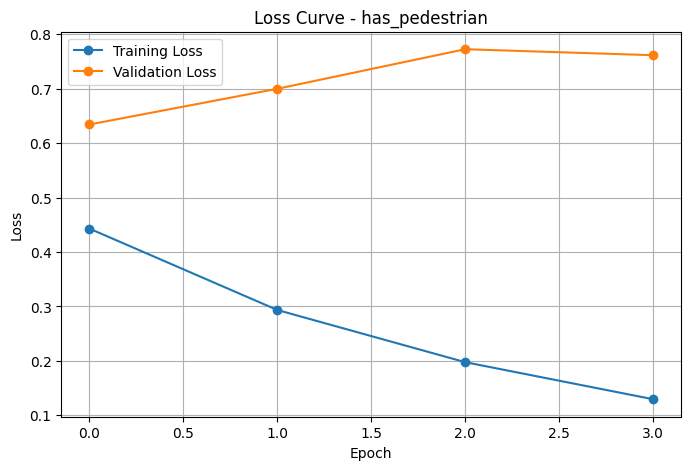

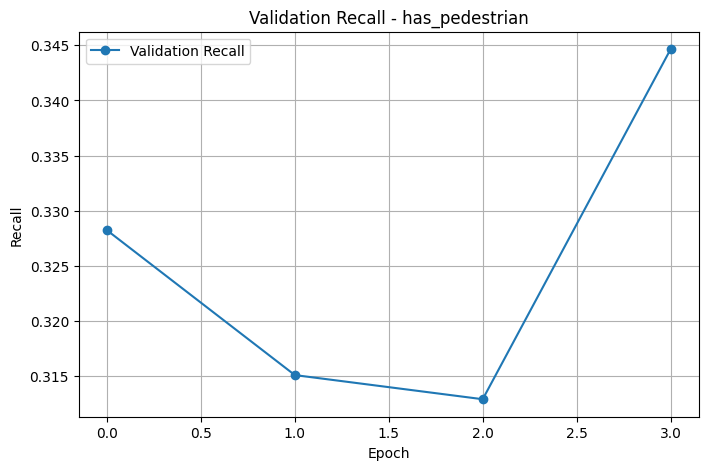


Best Validation Recall for has_pedestrian: 0.3446
Saved: has_pedestrian_model.pth

Training Model For: has_traffic_light


Epoch 1/4: 100%|██████████| 225/225 [00:55<00:00,  4.02it/s]


Epoch [1/4] | Train Loss: 0.1342 | Val Loss: 0.0803 | Val Recall: 0.9786
  -> Best model saved (Validation Recall = 0.9786)


Epoch 2/4: 100%|██████████| 225/225 [00:56<00:00,  4.02it/s]


Epoch [2/4] | Train Loss: 0.0469 | Val Loss: 0.0656 | Val Recall: 0.9830
  -> Best model saved (Validation Recall = 0.9830)


Epoch 3/4: 100%|██████████| 225/225 [00:56<00:00,  3.99it/s]


Epoch [3/4] | Train Loss: 0.0272 | Val Loss: 0.0772 | Val Recall: 0.9871
  -> Best model saved (Validation Recall = 0.9871)


Epoch 4/4: 100%|██████████| 225/225 [00:57<00:00,  3.91it/s]


Epoch [4/4] | Train Loss: 0.0200 | Val Loss: 0.0634 | Val Recall: 0.9842


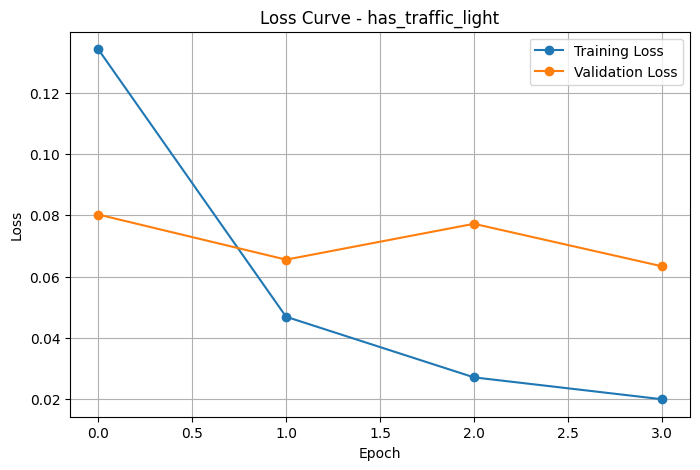

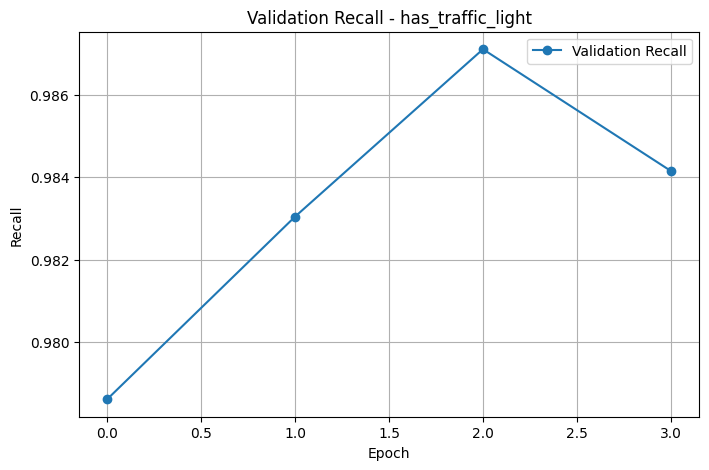


Best Validation Recall for has_traffic_light: 0.9871
Saved: has_traffic_light_model.pth

Training Model For: has_vehicle


Epoch 1/4: 100%|██████████| 225/225 [00:56<00:00,  3.97it/s]


Epoch [1/4] | Train Loss: 0.3233 | Val Loss: 0.2963 | Val Recall: 0.9050
  -> Best model saved (Validation Recall = 0.9050)


Epoch 2/4: 100%|██████████| 225/225 [00:57<00:00,  3.95it/s]


Epoch [2/4] | Train Loss: 0.1818 | Val Loss: 0.2999 | Val Recall: 0.8590


Epoch 3/4: 100%|██████████| 225/225 [00:55<00:00,  4.05it/s]


Epoch [3/4] | Train Loss: 0.1348 | Val Loss: 0.2740 | Val Recall: 0.9067
  -> Best model saved (Validation Recall = 0.9067)


Epoch 4/4: 100%|██████████| 225/225 [00:57<00:00,  3.90it/s]


Epoch [4/4] | Train Loss: 0.1107 | Val Loss: 0.3147 | Val Recall: 0.9075
  -> Best model saved (Validation Recall = 0.9075)


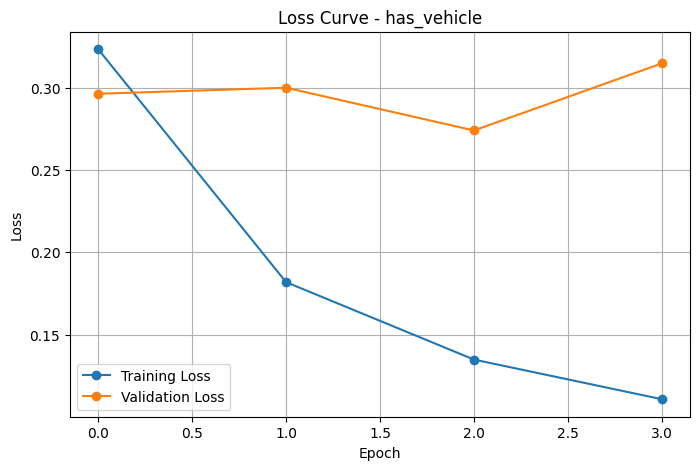

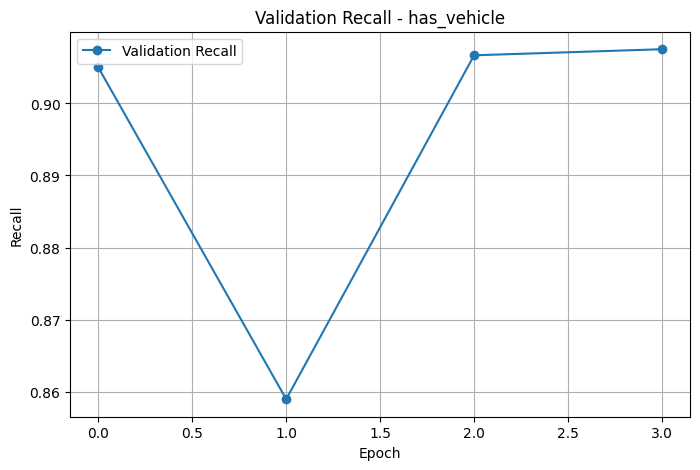


Best Validation Recall for has_vehicle: 0.9075
Saved: has_vehicle_model.pth


In [ ]:
import os
from PIL import Image
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import recall_score
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


tasks = [
    "has_pedestrian",
    "has_traffic_light",
    "has_vehicle"
]


for task in tasks:

    print(f"\nTraining Model For: {task}")

    train_dataset = CarlaDataset(
        dataframe=labels_train,
        image_dir=train_rgb_path,
        label_column=task,
        transform= model_transform
    )

    validation_dataset = CarlaDataset(
        dataframe=labels_validation,
        image_dir=validation_rgb_path,
        label_column=task,
        transform=model_transform
    )
    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=2
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=2
    )

    model = create_model().to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.0001
    )

    train_losses = []
    val_losses = []
    val_recalls = []

    best_val_recall = -1.0

    epochs = 4

    for epoch in range(epochs):

        model.train()

        running_train_loss = 0.0

        for images, labels in tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs}"
        ):

            images = images.to(device)

            labels = (
                labels
                .float()
                .unsqueeze(1)
                .to(device)
            )

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = (
            running_train_loss /
            len(train_loader)
        )

        train_losses.append(
            avg_train_loss
        )

        model.eval()

        running_val_loss = 0.0

        val_true = []
        val_pred = []

        with torch.no_grad():

            for images, labels in validation_loader:

                images = images.to(device)

                labels = (
                    labels
                    .float()
                    .unsqueeze(1)
                    .to(device)
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += loss.item()

                probabilities = torch.sigmoid(
                    outputs
                )

                predictions = (
                    probabilities > 0.5
                ).int()

                val_true.extend(
                    labels.cpu()
                    .numpy()
                    .astype(int)
                    .flatten()
                )

                val_pred.extend(
                    predictions.cpu()
                    .numpy()
                    .astype(int)
                    .flatten()
                )

        avg_val_loss = (
            running_val_loss /
            len(validation_loader)
        )

        val_losses.append(
            avg_val_loss
        )

        val_recall = recall_score(
            val_true,
            val_pred,
            zero_division=0
        )

        val_recalls.append(
            val_recall
        )

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Recall: {val_recall:.4f}"
        )

        if val_recall > best_val_recall:

            best_val_recall = val_recall

            torch.save(
                model.state_dict(),
                f"/content/drive/MyDrive/Data2/model/"
                f"{task}_model.pth"
            )

            print(
                f"  -> Best model saved "
                f"(Validation Recall = "
                f"{best_val_recall:.4f})"
            )

    plt.figure(figsize=(8, 5))

    plt.plot(
        train_losses,
        marker="o",
        label="Training Loss"
    )

    plt.plot(
        val_losses,
        marker="o",
        label="Validation Loss"
    )

    plt.title(
        f"Loss Curve - {task}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True)

    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        val_recalls,
        marker="o",
        label="Validation Recall"
    )

    plt.title(
        f"Validation Recall - {task}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Recall")

    plt.legend()
    plt.grid(True)

    plt.show()

    print(
        f"\nBest Validation Recall for {task}: "
        f"{best_val_recall:.4f}"
    )

    print(
        f"Saved: {task}_model.pth"
    )

Exercise 3.6

In [ ]:
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, data_loader, device="cpu"):
    model.eval()
    all_labels = []
    all_predictions = []

    model.to(device)

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)

            predictions = torch.sigmoid(outputs)
            predictions = (predictions > 0.5).int()

            all_predictions.extend(
                predictions.cpu().numpy().flatten()
            )

            all_labels.extend(
                labels.cpu().numpy().flatten()
            )
    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)

    return accuracy, precision, recall, f1

In [ ]:
import pandas as pd
import os
from torch.utils.data import DataLoader
from PIL import Image
dataset_paths = {
    "Validation": "/content/drive/MyDrive/Data2/validation",
    "Test": "/content/drive/MyDrive/Data2/test",
    "Test-Fog": "/content/drive/MyDrive/Data2/test-fog",
    "Test-Night": "/content/drive/MyDrive/Data2/test-night",
    "Test-Town-01": "/content/drive/MyDrive/Data2/test-town-01"
}

def evaluate_all_splits(model, task):

    results = []

    for split_name, split_path in dataset_paths.items():

        labels = pd.read_csv(split_path + "/labels.csv")

        dataset = CarlaDataset(
            dataframe=labels,
            image_dir=split_path + "/rgb-front",
            label_column=task,
            transform=model_transform
        )

        loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=False
        )

        accuracy, precision, recall, f1 = evaluate_model(
            model,
            loader,
            device
        )

        print(f"\n{split_name}")
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-Score : {f1:.4f}")

        results.append({
            "Dataset": split_name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

    return pd.DataFrame(results)

In [ ]:
task = "has_pedestrian"

model = create_model().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_pedestrian_model.pth",
        map_location=device
    )
)

model.eval()

pedestrian_results = evaluate_all_splits(model, task)

pedestrian_results


Validation
Accuracy : 0.7372
Precision: 0.4758
Recall   : 0.3446
F1-Score : 0.3997

Test
Accuracy : 0.7281
Precision: 0.3600
Recall   : 0.4972
F1-Score : 0.4176

Test-Fog
Accuracy : 0.7614
Precision: 0.3507
Recall   : 0.2019
F1-Score : 0.2563

Test-Night
Accuracy : 0.6658
Precision: 0.2738
Recall   : 0.3893
F1-Score : 0.3215

Test-Town-01
Accuracy : 0.6675
Precision: 0.1342
Recall   : 0.4923
F1-Score : 0.2109


,Dataset,Accuracy,Precision,Recall,F1-Score
0,Validation,0.737222,0.475831,0.344639,0.399746
1,Test,0.728056,0.360000,0.497167,0.417609
2,Test-Fog,0.761389,0.350711,0.201910,0.256277
3,Test-Night,0.665833,0.273775,0.389344,0.321489
4,Test-Town-01,0.667500,0.134228,0.492308,0.210943


In [ ]:
task = "has_traffic_light"

model = create_model().to(device)

model.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/Data2/model/has_traffic_light_model.pth",
        map_location=device
    )
)

model.eval()

traffic_results = evaluate_all_splits(model, task)


traffic_results


Validation
Accuracy : 0.9803
Precision: 0.9867
Recall   : 0.9871
F1-Score : 0.9869

Test
Accuracy : 0.9411
Precision: 0.9360
Recall   : 0.9853
F1-Score : 0.9600

Test-Fog
Accuracy : 0.5600
Precision: 0.9702
Recall   : 0.4094
F1-Score : 0.5758

Test-Night
Accuracy : 0.4033
Precision: 0.9597
Recall   : 0.1903
F1-Score : 0.3177

Test-Town-01
Accuracy : 0.7919
Precision: 0.8288
Recall   : 0.8793
F1-Score : 0.8533


,Dataset,Accuracy,Precision,Recall,F1-Score
0,Validation,0.980278,0.986735,0.987099,0.986917
1,Test,0.941111,0.936029,0.985294,0.960030
2,Test-Fog,0.560000,0.970217,0.409368,0.575790
3,Test-Night,0.403333,0.959693,0.190331,0.317662
4,Test-Town-01,0.791944,0.828767,0.879289,0.853281
